# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Rifky Afrizal Saputra]
- **Email:** [rifky.23266@mhs.unesa.ac.id]
- **ID Dicoding:** [CDCC284D6Y1610]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Bulan apa yang memiliki jumlah penyewaan sepeda tertinggi selama periode 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

Pada tahap ini dilakukan proses pembersihan dan transformasi data agar siap untuk dianalisis.
Beberapa langkah yang dilakukan antara lain:
- Mengubah tipe data kolom tanggal menjadi format datetime
- Mengubah variabel kategorikal menjadi label yang lebih mudah dipahami
- Memastikan tidak terdapat missing value yang dapat mempengaruhi hasil analisis

Tujuan dari tahap ini adalah untuk memastikan kualitas data sehingga hasil analisis menjadi lebih akurat dan dapat dipercaya.

### Gathering Data

Pada tahap ini dilakukan proses pengumpulan data yang akan digunakan dalam analisis. Dataset yang digunakan adalah Bike Sharing Dataset yang berisi data penyewaan sepeda harian selama periode tahun 2011–2012.

Data diambil dari file `day.csv` yang kemudian dimuat ke dalam DataFrame menggunakan library pandas. Dataset ini mencakup berbagai variabel penting seperti tanggal, musim, kondisi cuaca, suhu, serta jumlah penyewaan sepeda (cnt).

Tujuan dari tahap ini adalah untuk memastikan data berhasil dimuat dengan baik dan siap untuk dilakukan proses analisis lebih lanjut.

In [2]:
df = pd.read_csv("data/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset berisi data penyewaan sepeda harian
- Terdapat beberapa variabel seperti cuaca, musim, suhu dan jumlah penyewaan

### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data secara menyeluruh untuk memastikan data layak digunakan dalam analisis.

Beberapa langkah yang dilakukan antara lain:
- Memeriksa struktur dan tipe data menggunakan `df.info()`
- Menampilkan statistik deskriptif menggunakan `df.describe()`
- Mengecek missing value menggunakan `df.isna().sum()`
- Mengecek duplikasi data menggunakan `df.duplicated().sum()`
- Melihat distribusi variabel kategorikal menggunakan `value_counts()`

Tujuan dari tahap ini adalah untuk mengidentifikasi potensi masalah seperti data hilang, duplikasi, atau ketidaksesuaian tipe data yang dapat mempengaruhi hasil analisis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [6]:
df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['season'].value_counts()
df['weathersit'].value_counts()

,count
weathersit,
1,463
2,247
3,21


**Insight:**
- Tidak terdapat missing value yang signifikan
- Tidak terdapat data duplikat sehingga data bersih dari redundasi.
- Terdapat beberapa variabel kategorikal seperti season dan weathersit yang terdisbusi tidak rata.

### Cleaning Data

Pada tahap ini dilakukan proses pembersihan dan transformasi data agar lebih mudah dianalisis.

Beberapa langkah yang dilakukan antara lain:
- Mengubah tipe data kolom `dteday` dari object menjadi datetime untuk memudahkan analisis berbasis waktu.
- Mengubah variabel kategorikal seperti `season` dan `weathersit` dari bentuk numerik menjadi label yang lebih deskriptif dan mudah dipahami.
- Memastikan tidak terdapat missing value atau data duplikat sehingga tidak diperlukan proses tambahan seperti imputasi atau penghapusan data.

Tujuan dari tahap ini adalah untuk meningkatkan kualitas dan keterbacaan data sehingga hasil analisis menjadi lebih akurat dan mudah diinterpretasikan.

In [9]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['season'] = df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

df['weathersit'] = df['weathersit'].map({
    1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})

**Insight:**
- Kolom 'dteday' berhasil di ubah ke format datetime untuk memudahkan analisis berbasis waktu.
- Variabel kategorikal seperti 'season' dan 'weathersit' telah di ubah menjadi label yang lebih mudah dipahami.
- Tidak ditemukan missing value, sehingga tidak diperlukan proses imputasi atau penghapusan data.

## Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk memahami karakteristik data dan menemukan pola awal yang dapat menjawab pertanyaan bisnis.

Analisis difokuskan pada:
- Hubungan antara kondisi cuaca dengan jumlah penyewaan sepeda
- Pola penyewaan berdasarkan waktu (bulan)

Melalui EDA, diharapkan dapat ditemukan insight awal yang akan diperkuat melalui visualisasi data.

In [11]:
df.groupby("weathersit")["cnt"].mean()

,cnt
weathersit,
Clear,4876.786177
Light Snow/Rain,1803.285714
Mist,4035.862348


In [12]:
df.groupby("mnth")["cnt"].sum()

,cnt
mnth,
1,134933
2,151352
3,228920
4,269094
5,331686
6,346342
7,344948
8,351194
9,345991


**Insight:**
- Cuaca cerah (Clear) memiliki rata-rata jumlah penyewaan sepeda tertinggi.
- Cuaca buruk seperti hujan ringan/salju memiliki jumlah penyewaan lebih rendah.
- Penyewaan sepeda cenderung meningkat pada bulan-bulan tertentu (indikasi pola musiman).
- Bulan dengan total penyewaan tertinggi dapat diidentifikasi melalui agregasi data bulanan, yang menunjukkan adanya pola musiman dalam penggunaan sepeda.

## Visualization & Explanatory Analysis

Visualisasi dilakukan untuk menyajikan hasil analisis secara lebih intuitif dan mudah dipahami.

Grafik yang digunakan:
- Bar chart untuk melihat pengaruh kondisi cuaca terhadap jumlah penyewaan
- Line chart untuk melihat tren penyewaan sepeda per bulan

Tujuan dari visualisasi ini adalah untuk membantu mengidentifikasi pola dan perbandingan secara visual sehingga memudahkan dalam pengambilan kesimpulan.

### Pertanyaan 1:

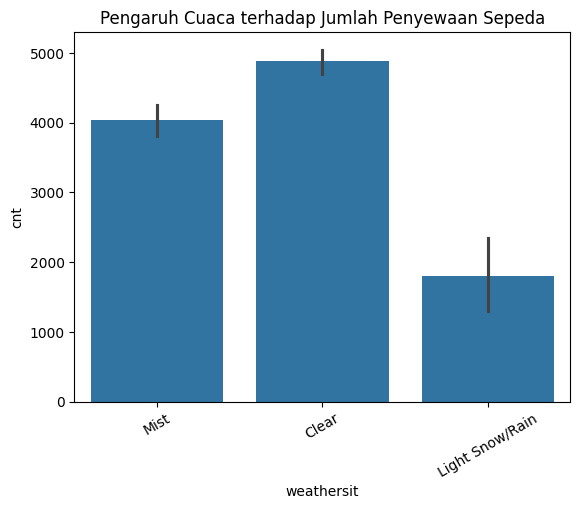

In [13]:
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda")
plt.xticks(rotation=30)
plt.show()

### Pertanyaan 2:

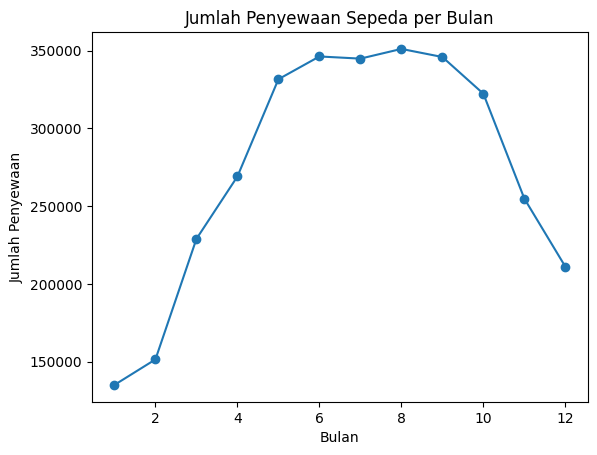

In [14]:
monthly = df.groupby("mnth")["cnt"].sum()

plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Jumlah Penyewaan Sepeda per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight:**
- Grafik menunjukan bahwa kondisi cuaca sangat mempengaruhi jumlah penyewaan sepeda.
- Cuaca cerah secara signifikan meningkatkan jumlah penyewaan sepeda karena kondisi tersebut lebih mendukung aktivitas luar ruangan.
- Tren bulanan menunjukan adanya kenaikan penyewaan di pertengahan tahun.
- Bulan dengan penyewaan tertinggi kemungkinan berada pada musim panas atau musim gugur.

## Analisis Lanjutan (Opsional)

Pada tahap ini dilakukan pengelompokan data (clustering sederhana) menggunakan teknik binning berdasarkan jumlah penyewaan sepeda.

Data dibagi menjadi beberapa kategori:
- Rendah (Low)
- Sedang (Medium)
- Tinggi (High)

Tujuan dari analisis ini adalah untuk mengelompokkan hari berdasarkan tingkat aktivitas penyewaan, sehingga dapat membantu dalam memahami pola penggunaan sepeda secara lebih spesifik.

In [17]:
df['kategori_penyewaan'] = pd.qcut(df['cnt'], q=3, labels=["Rendah", "Sedang", "Tinggi"])
df.groupby("kategori_penyewaan", observed=False)["cnt"].mean()

,cnt
kategori_penyewaan,
Rendah,2312.065574
Sedang,4522.225410
Tinggi,6687.703704


## Conclusion

- Conclution pertanyaan 1, kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah menghasilkan jumlah penyewaan tertinggi, sedangkan kondisi cuaca buruk seperti hujan atau salju menurunkan minat pengguna untuk menyewa sepeda.
- Conclution pertanyaan 2, jumlah penyewaan sepeda tertinggi terjadi pada bulan-bulan tertentu dipertengahan tahun, yang kemungkinan berkaitan dengan musim panas atau kondisi cuaca yang lebih mendukung aktivitas luar ruangan.